# Test Model on New Dataset (Autoregressive Prediction)

Este notebook permite cargar un modelo entrenado (archivos `.pt`) y probarlo en un dataset completamente nuevo (archivo `.csv`).

**Flujo de Evaluación:**
1. **Carga el modelo y sus pesos**: Usando las clases `GRUPINN` y `SoilPhysics` del proyecto.
2. **Carga el nuevo `csv`**: Agrupa por puntos espaciales (X, Y).
3. **Filtrado (Opcional)**: Aplica filtro Savitzky-Golay a la serie `u` para reducir ruido.
4. **Normaliza los datos**: Ajustando a las estadísticas locales o globales.
5. **Predicción Autoregresiva**: 
   - Toma 5 días reales -> Predice el 6to.
   - Usa esa predicción (junto con datos reales de lluvia/tiempo) para predecir el 7mo, y así sucesivamente.
6. **Grafica Real vs Predicho**.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os
from scipy.signal import savgol_filter

# Añadir directorio raíz al path para importar módulos
current_dir = Path(os.getcwd())
if str(current_dir) not in sys.path:
    sys.path.append(str(current_dir))

# Importar módulos del proyecto
from models.gru_pinn import GRUPINN
from models.physics import SoilPhysics

# ==========================================
# 1. CONFIGURACIÓN (EDITAR AQUI)
# ==========================================

# Archivo del modelo entrenado (pesos)
MODEL_PATH = "outputs/models/MedellinOriental_longterm_gru_final.pt"

# Archivo CSV con el NUEVO dataset a probar
CSV_PATH = r"C:/Users/julia/MGEO/THESIS/DEFORMATION_DATA/culstered_landslides_forNN_withRainfall/long_term_prediction/MedellinOriental_10percent.csv"

# Columnas de entrada (deben coincidir con el entrenamiento)
FEATURE_COLS = ['u', 'X', 'Y', 'p_acum_30d', 'p_acum_60d', 'p_acum_90d', 't_days']
TARGET_COL = 'u'

# Parámetros de secuencia
N_STEPS_IN = 10  # Ventana de entrada (5 días)
DT_DAYS = 12.0  # Paso de tiempo aproximado entre imágenes (ajustar si es diferente)

# Filtro Savitzky-Golay
USE_SAVGOL = True
SAVGOL_WINDOW = 10 
SAVGOL_POLY = 2

# Dispositivo
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cuda


## 2. Cargar Datos y Normalizar

In [2]:
# A. Cargar CSV
print(f"Leyendo dataset: {CSV_PATH}...")
df = pd.read_csv(CSV_PATH)
print(f"Filas totales: {len(df)}")

# Verificar si hay múltiples puntos (agrupar por X, Y)
if 'X' in df.columns and 'Y' in df.columns:
    df['point_id'] = df.apply(lambda row: f"{row['X']}_{row['Y']}", axis=1)
else:
    df['point_id'] = "single_point"

unique_points = df['point_id'].unique()
print(f"Puntos únicos encontrados: {len(unique_points)}")

# A.1. FILTRADO SAVITZKY-GOLAY (Opcional)
if USE_SAVGOL:
    print("\nAplicando filtro Savitzky-Golay a la columna 'u'...")
    
    def apply_savgol(group):
        if len(group) > SAVGOL_WINDOW:
            return savgol_filter(group, window_length=SAVGOL_WINDOW, polyorder=SAVGOL_POLY)
        return group
    
    # Ordenar por tiempo antes de filtrar
    df = df.sort_values(by=['point_id', 't_days'])
    
    # Guardar original para comparar
    df['u_raw'] = df['u'].copy()
    
    # Aplicar filtro por grupo
    df['u'] = df.groupby('point_id')['u'].transform(apply_savgol)
    print("✅ Datos suavizados.")

# B. Normalización
# Escalamos TODO el dataset junto para tener estadísticas consistentes
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_features = df[FEATURE_COLS].copy()
scaler.fit(df_features)

# Obtener estadísticas específicas para des-escalar 'u'
u_idx = FEATURE_COLS.index('u')
u_mean = scaler.mean_[u_idx]
u_scale = scaler.scale_[u_idx]

print(f"Estadísticas de 'u': Mean={u_mean:.4f}, Scale={u_scale:.4f}")

def scale_value(val, col_name):
    idx = FEATURE_COLS.index(col_name)
    return (val - scaler.mean_[idx]) / scaler.scale_[idx]

def descale_u(u_sc):
    return (u_sc * u_scale) + u_mean

: 

## 3. Cargar Modelo

In [43]:
print(f"\nCargando modelo desde: {MODEL_PATH}...")
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

# Recuperar configuración
model_conf = checkpoint['model_config']
input_size = len(FEATURE_COLS)
hidden_size = model_conf.get('hidden_size', 128)
num_layers = model_conf.get('num_layers', 2)

# Instanciar Modelos
model = GRUPINN(input_size, hidden_size, num_layers, dropout=0.0).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

soil_physics = SoilPhysics(device=DEVICE)
soil_physics.load_state_dict(checkpoint['soil_physics_state_dict'])

# Mostrar parámetros físicos aprendidos
params = soil_physics.get_params()
print("\nParámetros Físicos Aprendidos:")
for k, v in params.items():
    print(f"  {k}: {v.item():.4f}")

print("✅ Modelos cargados correctamente.")


Cargando modelo desde: outputs/models/MedellinOriental_longterm_gru_final.pt...

Parámetros Físicos Aprendidos:
  c_prime: 6.3968
  phi: 26.4272
  n: 1.4027
  sigma_n: 51.4340
  eta: 200000.0000
  tau: 15.0000
  h: 15.0000
✅ Modelos cargados correctamente.


C:\Users\julia\AppData\Local\Temp\ipykernel_38936\2984096460.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)


## 4. Predicción Autoregresiva (Loop Principal)

Para cada punto:
1. Tomamos los primeros 5 datos REALES (ventana inicial).
2. Predecimos paso 6.
3. Usamos predicción 6 como entrada para predecir 7 (mixed con datos reales de lluvia/tiempo).
4. Repetimos hasta el final.

In [44]:
results = {}

model.eval()
soil_physics.eval()

with torch.no_grad():
    for pid in unique_points[:10]: # Probar con primeros 5 puntos para no saturar
        print(f"\nProcesando punto: {pid}")
        
        # Filtrar datos del punto y ordenar por tiempo
        df_point = df[df['point_id'] == pid].sort_values('t_days').reset_index(drop=True)
        
        if len(df_point) <= N_STEPS_IN:
            print(f"  -> Serie muy corta ({len(df_point)}), saltando.")
            continue
            
        # Datos reales completos (para comparar y para inputs exógenos)
        # Escalamos todo el dataframe del punto
        data_scaled = scaler.transform(df_point[FEATURE_COLS])
        
        # Listas para guardar historia
        # Inicializamos con la ventana real (primeros 5 pasos)
        history_predictions = []      # Guardar predicciones (escaladas)
        real_u_values = df_point['u'].values
        real_u_raw_values = df_point['u_raw'].values if 'u_raw' in df_point.columns else real_u_values
        
        # Ventana inicial: pasos 0 a 4 (índices 0,1,2,3,4)
        current_window = data_scaled[:N_STEPS_IN].copy() # shape (5, n_features)
        
        # U previo para física (el último real conocido antes de empezar a predecir)
        # En t=5 (primer paso a predecir), el u_prev es el de t=4
        last_u_real_scaled = current_window[-1, u_idx]
        last_u_real = descale_u(last_u_real_scaled)
        
        # Loop de predicción paso a paso desde t=5 hasta el final
        for t in range(N_STEPS_IN, len(df_point)):
            # 1. Preparar input tensor
            # current_window tiene shape (5, features)
            X_in = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0).to(DEVICE) # (1, 5, features)
            
            # 2. Calcular componente física
            # Necesitamos u_prev REAL (no escalado) para las ecuaciones físicas
            # Si es el primer paso, usamos el real. Si no, usamos el predicho anterior.
            if len(history_predictions) == 0:
                u_prev_for_physics = last_u_real
            else:
                # Última predicción (está escalada, hay que des-escalar)
                u_prev_for_physics = descale_u(history_predictions[-1])
            
            u_prev_tensor = torch.tensor([[u_prev_for_physics]], dtype=torch.float32).to(DEVICE)
            
            # Predicción física
            # Nota: Usamos DT fijo o calculado del dataset si t varia
            u_physics = soil_physics.compute_displacement(u_prev_tensor, dt_days=DT_DAYS)
            
            # Escalar componente física para sumar a la red (que entrena en espacio escalado si usaste esa lógica)
            # OJO: Depende de cómo se entrenó. Si el target era (u-mu)/sigma, la red predice en ese espacio.
            # El término físico debe sumarse en el mismo espacio.
            u_physics_scaled = (u_physics - u_mean) / u_scale
            
            # 3. Predicción Red Neuronal (Residual + Física)
            # El modelo GRUPINN ya suma: output = u_physics_scaled + delta_u_nn
            pred_scaled_tensor = model(X_in, u_physics_scaled)
            pred_scaled = pred_scaled_tensor.item()
            
            # 4. Guardar predicción
            history_predictions.append(pred_scaled)
            
            # 5. Actualizar ventana para el siguiente paso
            # Desplazar ventana una posición atrás
            # Nuevo paso t (el que acabamos de predecir se convierte en el pasado para t+1)
            
            if t < len(df_point) - 1:
                # Crear nueva fila de features
                new_row = data_scaled[t].copy() # Tomamos datos REALES de lluvia, tiempo, X, Y
                
                # REEMPLAZAR la columna 'u' con nuestra PREDICCIÓN
                new_row[u_idx] = pred_scaled
                
                # Actualizar ventana: quitar primero, agregar nuevo al final
                current_window = np.vstack([current_window[1:], new_row])
        
        # Guardar resultados del punto
        preds_real_scale = [descale_u(p) for p in history_predictions]
        
        # Alinear: Predicciones empiezan en t=N_STEPS_IN
        # Real values correspondientes: df_point['u'].values[N_STEPS_IN:]
        
        results[pid] = {
            "real_filtered": real_u_values[N_STEPS_IN:],
            "real_raw": real_u_raw_values[N_STEPS_IN:],
            "pred": np.array(preds_real_scale),
            "time": df_point['t_days'].values[N_STEPS_IN:]
        }
        
        print(f"  -> Predicción finalizada. RMSE Autoregresivo: {np.sqrt(np.mean((results[pid]['real_filtered'] - results[pid]['pred'])**2)):.4f}")


Procesando punto: 4719942.352441843_2250708.201519075
  -> Predicción finalizada. RMSE Autoregresivo: 0.0130

Procesando punto: 4719942.159417396_2250668.1878993064
  -> Predicción finalizada. RMSE Autoregresivo: 0.0163

Procesando punto: 4719861.693839795_2250588.546962084
  -> Predicción finalizada. RMSE Autoregresivo: 0.0132

Procesando punto: 4720261.898440816_2250546.603033798
  -> Predicción finalizada. RMSE Autoregresivo: 0.0067

Procesando punto: 4720301.938145178_2250546.410157255
  -> Predicción finalizada. RMSE Autoregresivo: 0.0106

Procesando punto: 4720101.5466442425_2250507.3612426864
  -> Predicción finalizada. RMSE Autoregresivo: 0.0128

Procesando punto: 4719901.154603279_2250468.312910809
  -> Predicción finalizada. RMSE Autoregresivo: 0.0159

Procesando punto: 4720101.35378598_2250467.347669036
  -> Predicción finalizada. RMSE Autoregresivo: 0.0126

Procesando punto: 4720141.39358957_2250467.1547037144
  -> Predicción finalizada. RMSE Autoregresivo: 0.0106

Procesa

## 5. Visualización de Resultados

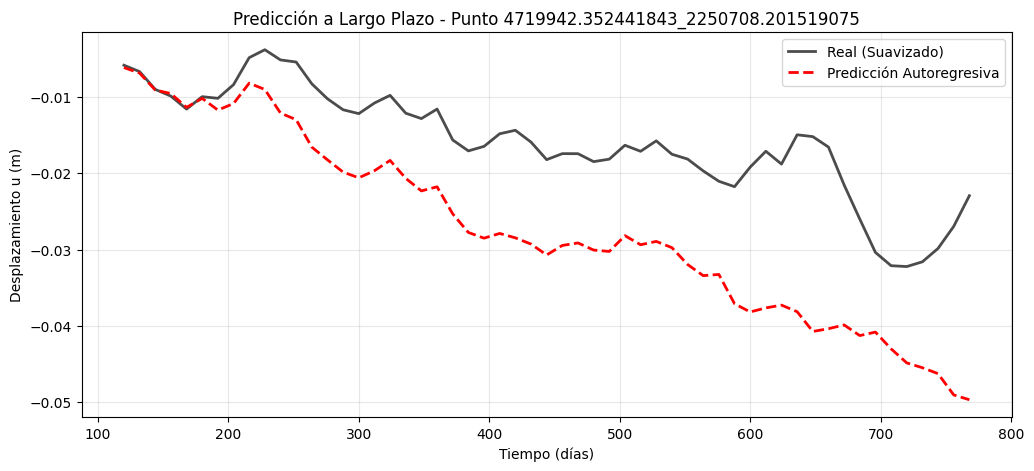

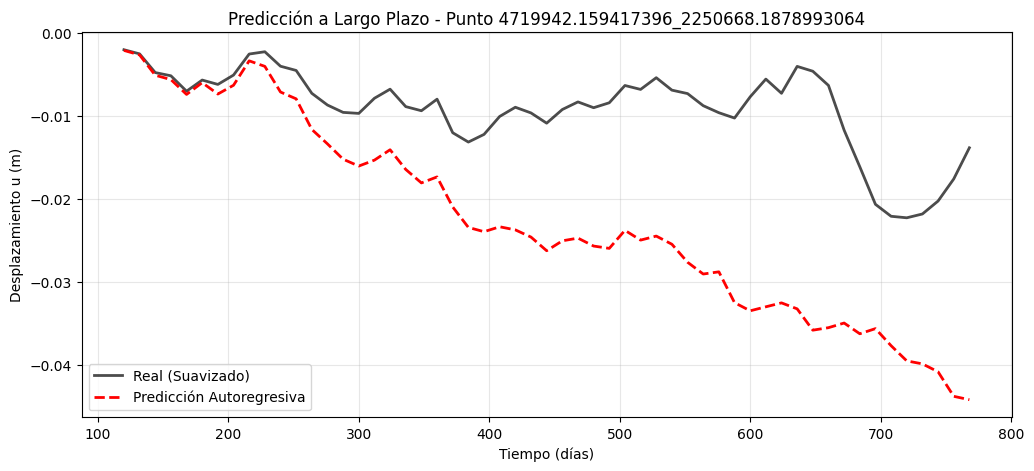

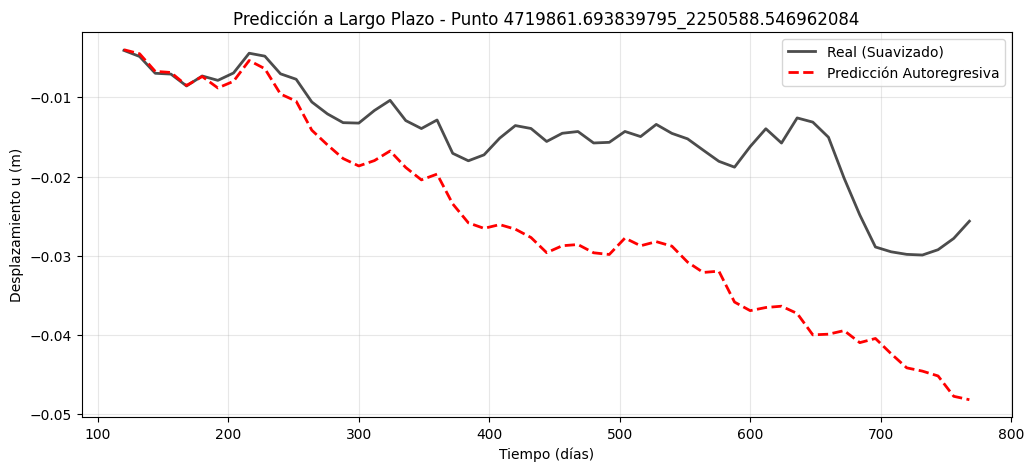

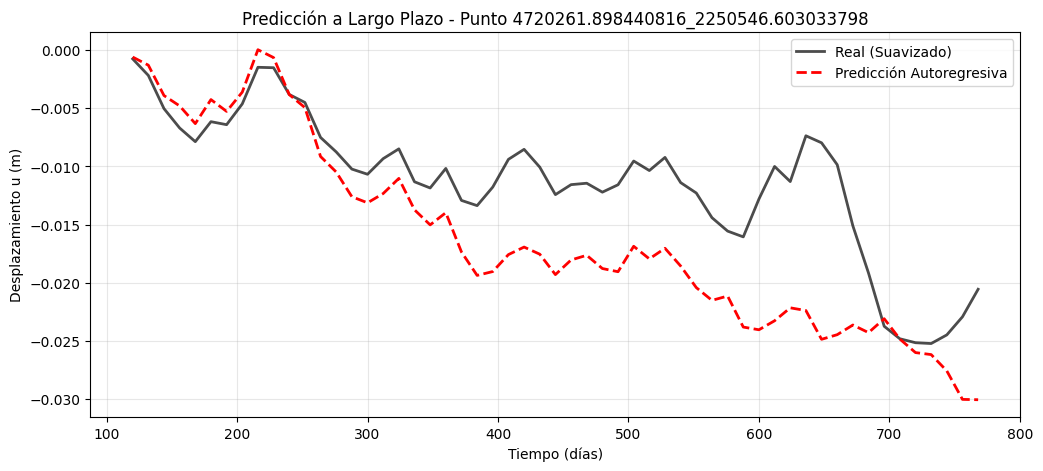

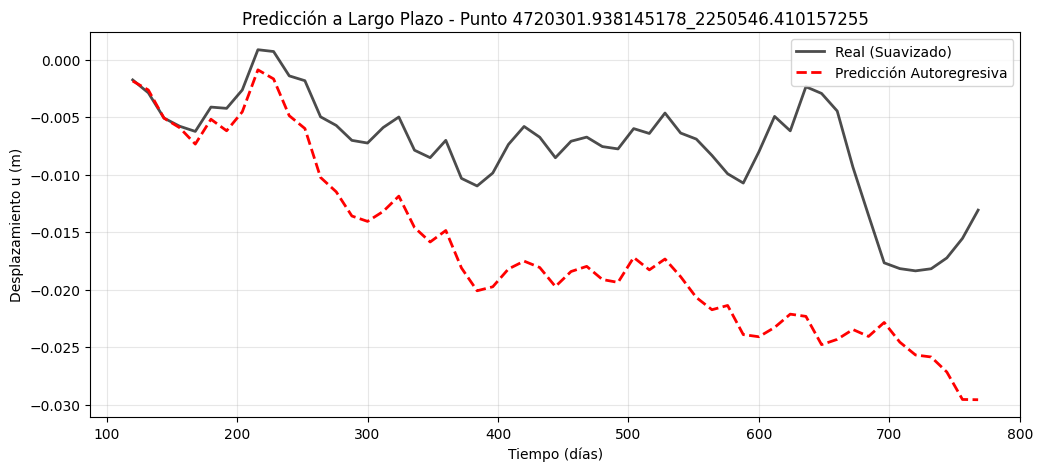

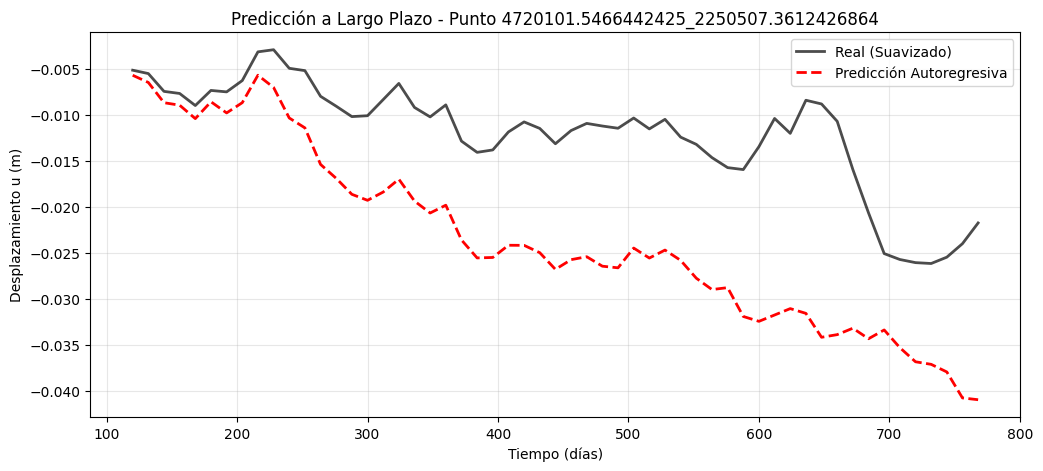

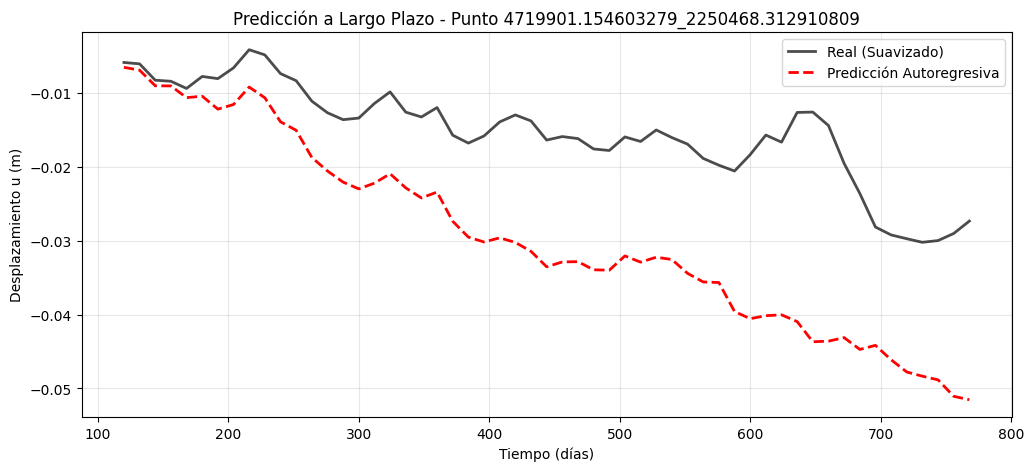

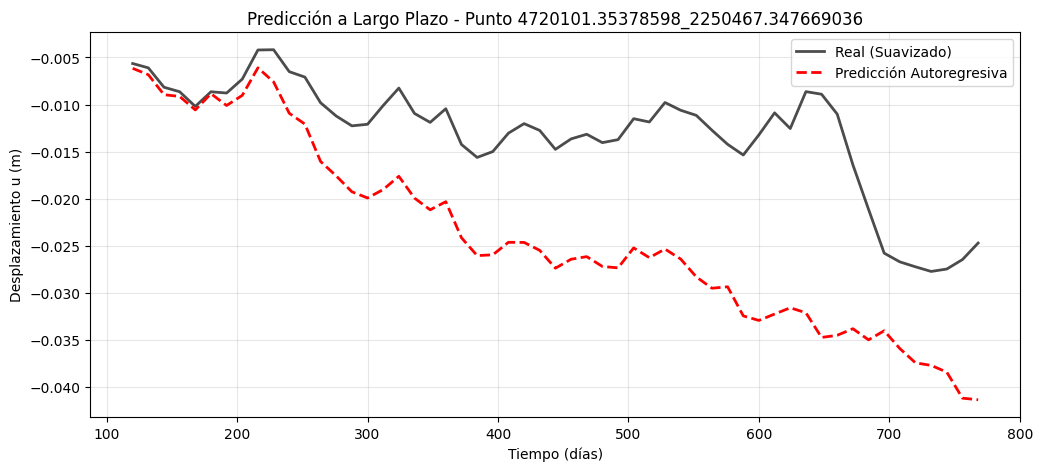

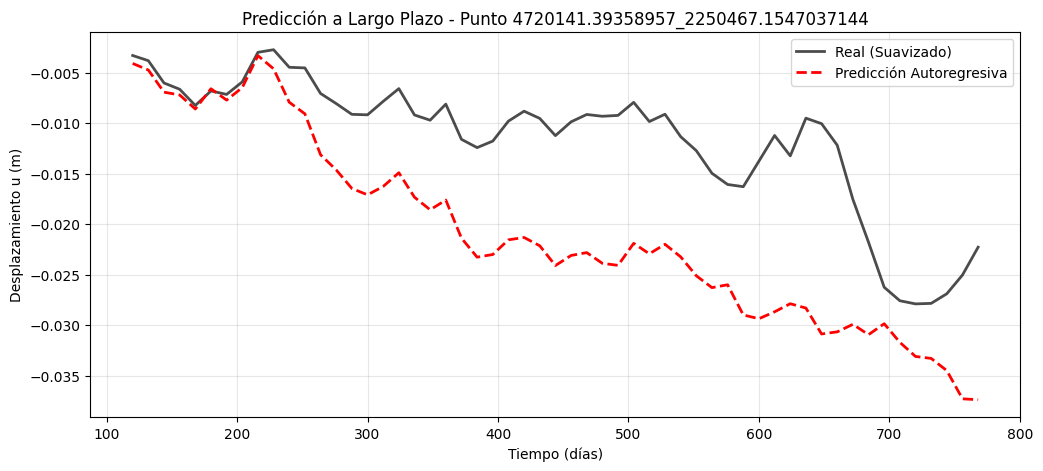

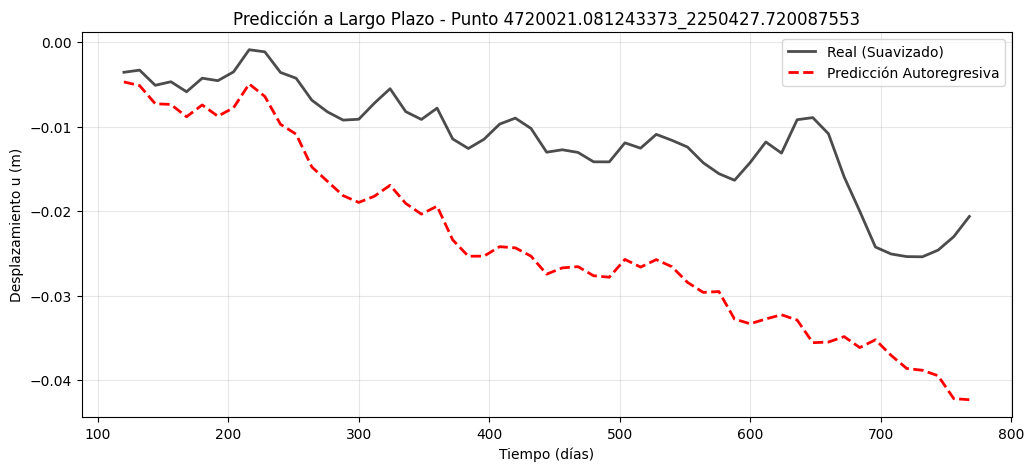

In [45]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ---------------------------------------------------------
# VISUALIZACIÓN MEJORADA CON FONDO DINÁMICO (RMSE)
# ---------------------------------------------------------

# Configuración de la figura
n_points = len(results)
if n_points == 0:
    print("No hay resultados para mostrar.")
else:
    # Crear subplots (uno por cada punto, apilados verticalmente o en grilla)
    # Por simplicidad, usamos una figura larga vertical si son muchos puntos
    fig, axes = plt.subplots(nrows=n_points, ncols=1, figsize=(12, 5 * n_points), constrained_layout=True)
    
    # Asegurar que axes sea iterable aunque haya solo un punto
    if n_points == 1:
        axes = [axes]
    
    # Iterar sobre cada punto y su eje correspondiente
    for (pid, res), ax in zip(results.items(), axes):
        
        # Extraer datos
        real = res['real_filtered']  # Serie real suavizada (target)
        pred = res['pred']           # Serie predicha
        time = res['time']           # Eje de tiempo (días)
        real_raw = res.get('real_raw', real) # Serie real cruda (si existe)

        # -----------------------------------------------------
        # CÁLCULO DE RMSE EN VENTANAS MÓVILES (100 días)
        # -----------------------------------------------------
        window_size = 100
        rmse_series = []
        
        # Calcular el error cuadrático punto a punto
        squared_errors = (real - pred) ** 2
        
        # Calcular RMSE móvil
        # Usamos una lista para almacenar el RMSE centrado o alineado a la derecha
        # Aquí alineamos a la derecha para pintar el fondo del "pasado reciente"
        for i in range(len(squared_errors)):
            if i < window_size:
                # Al principio, tomamos lo que haya
                window_err = squared_errors[:i+1]
            else:
                window_err = squared_errors[i-window_size+1 : i+1]
            
            rmse_val = np.sqrt(np.mean(window_err))
            rmse_series.append(rmse_val)
            
        rmse_series = np.array(rmse_series)
        
        # -----------------------------------------------------
        # CONFIGURACIÓN DEL MAPA DE COLOR (Reds)
        # -----------------------------------------------------
        # Normalizar los valores de RMSE para el colormap
        # Un RMSE de 0 será blanco, un RMSE alto será rojo intenso.
        # Definimos un vmin y vmax razonables para la escala.
        vmin = 0.0
        vmax = np.percentile(rmse_series, 95) if len(rmse_series) > 0 else 1.0 # Usar el p95 para evitar outliers extremos
        if vmax == 0: vmax = 1.0
        
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.Reds

        # -----------------------------------------------------
        # GRAFICAR
        # -----------------------------------------------------
        
        # 1. Pintar el FONDO según el RMSE
        # Usamos axvspan para cada paso de tiempo o un pcolormesh de fondo
        # Para eficiencia, pintamos franjas verticales. 
        # Como 'time' puede no ser regular, itera por pasos.
        
        # Truco eficiente: pcolormesh/imshow con extent
        # Creamos una "imagen" de 1 fila y N columnas con los colores
        # Lo estiramos para cubrir todo el eje X y el rango Y del plot
        
        # Determinar límites Y para el fondo (usamos min/max de los datos)
        y_min_plot = min(np.min(real), np.min(pred))
        y_max_plot = max(np.max(real), np.max(pred))
        # Dar un poco de margen
        y_margin = (y_max_plot - y_min_plot) * 0.1
        y_lims = [y_min_plot - y_margin, y_max_plot + y_margin]

        # Crear malla para pcolormesh
        # X son los tiempos, Y son los límites fijos
        # RMSE define el color (C)
        
        # Para pcolormesh, necesitamos bordes de celdas. 
        # Si time tiene N puntos, necesitamos N+1 bordes o usar shading='auto'/'nearest'
        # Usamos ax.imshow con aspect='auto' y extent es más fácil visualmente para "fondo"
        
        # Opción B: Loop de axvspan (Lento si hay muchos puntos, pero preciso vectorialmente)
        # Opción C: Collection de rectángulos (Más rápido)
        # Opción D: scatter con marker cuadrado grande (Truco)
        
        # Vamos con la opción de COLORBAR/STRIP en la parte inferior o fondo completo.
        # El usuario pidió "fondo dinámico". Vamos a intentar axvspan discretizado para no matar el render.
        # O mejor: pcolormesh.
        
        # Preparamos coordenadas para pcolormesh
        # X_grid: bordes temporales (estimados como puntos medios)
        if len(time) > 1:
            dt = np.diff(time)
            # Bordes: t[0]-dt/2, t[0]+dt/2, ...
            # Simplificación: usaremos los tiempos exactos como centros
            X, Y = np.meshgrid(time, y_lims)
            
            # La matriz de colores debe tener shape (ny-1, nx-1) para flat shading
            # Aquí queremos que varíe solo en X.
            # Repetimos rmse_series para que tenga dimension (1, N)
            C = rmse_series.reshape(1, -1) 
            
            # PINTAR FONDO
            # shading='nearest' centra los colores en los puntos X
            im = ax.pcolormesh(time, y_lims, C, cmap=cmap, norm=norm, shading='nearest', alpha=0.3, zorder=0)
            
            # Añadir barra de color pequeña para referencia
            # cbar = plt.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.1)
            # cbar.set_label('RMSE (Ventana 100 días)')
        
        # 2. Graficar Series
        ax.plot(time, real, 'k-', lw=1.5, label='Real (Filtrado)', zorder=2)
        # ax.plot(time, real_raw, 'k--', lw=0.5, alpha=0.5, label='Real (Crudo)', zorder=1)
        ax.plot(time, pred, 'b--', lw=1.5, label='Predicción Autoregresiva', zorder=3)

        # 3. Decoración
        ax.set_title(f"Punto ID: {pid} | Desplazamiento Acumulado vs Tiempo", fontsize=12, fontweight='bold')
        ax.set_xlabel("Tiempo (días)")
        ax.set_ylabel("Desplazamiento u (escalado/norm)")
        ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Ajustar límites Y
        ax.set_ylim(y_lims)

    plt.show()
